# **Лабораторная работа 3: временные ряды**

Выполнил студент гр. J3212 Морозов Дмитрий. ИСУ 466761

## Теоретическая справка

Временной ряд можно представить как последовательность наблюдений

$$
\{x_t\}_{t=1}^{n},
$$

где $x_t$ — значение показателя в момент времени $t$. В этой работе ряд рассматривается как сумма полезной составляющей и случайных колебаний. Фильтрация нужна для того, чтобы уменьшить влияние локального шума и выделить более устойчивую динамику продаж.

### Скользящее среднее

Скользящее среднее заменяет каждую точку средним значением внутри окна фиксированной длины:

$$
\hat{x}_t = \frac{1}{m}\sum_{i=-r}^{r} x_{t+i}, \qquad m=2r+1.
$$

Метод прост и хорошо подавляет резкие случайные колебания, но при большом окне может сглаживать пики и запаздывать относительно исходного ряда.

### Фильтр Калмана

Используется одномерный дискретный фильтр Калмана с моделью случайного блуждания:

$$
x_t = x_{t-1} + w_t, \qquad z_t = x_t + v_t,
$$

где $x_t$ — скрытое истинное состояние ряда, $z_t$ — наблюдаемое значение, $w_t$ — шум процесса, $v_t$ — шум измерения. На каждом шаге фильтр сначала делает прогноз состояния, а затем уточняет его по новому наблюдению. Вес нового наблюдения определяется коэффициентом Калмана:

$$
K_t = \frac{P_t^-}{P_t^- + R}.
$$

Такой вариант подходит для продаж, если считать, что истинный уровень меняется постепенно, а отдельные наблюдения содержат шум.

### Фильтр Савицкого-Голея

Фильтр Савицкого-Голея строит локальную полиномиальную аппроксимацию внутри скользящего окна. Для точки $t$ подбирается полином степени $p$:

$$
q(s)=a_0+a_1s+\dots+a_ps^p,
$$

коэффициенты которого находятся методом наименьших квадратов по соседним точкам. Сглаженное значение берется как значение полинома в центре окна. Метод часто лучше сохраняет форму локальных максимумов и минимумов, чем обычное среднее.

In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.analysis import autocorrelation, correlation_matrix, descriptive_statistics, dominant_period
from src.data_loader import PRODUCT_COLUMNS, PRODUCT_LABELS, isu_to_variant, load_variant_data
from src.filters import kalman_random_walk, moving_average, savitzky_golay
from src.metrics import filtering_summary

plt.style.use("seaborn-v0_8-whitegrid")

## Загрузка данных

Номер ИСУ: `466761`

In [13]:
ISU_NUMBER = 466761
VARIANT = isu_to_variant(ISU_NUMBER)

data = load_variant_data(ROOT / "sell.csv", VARIANT)
print(f"Вариант: {VARIANT}")
data.head()

Вариант: 21


,day,soap,powder,cleaner,paint,foam,profit
0,1,71,20,19,44,19,26.418
1,2,101,16,20,46,19,29.583
2,3,87,27,19,44,18,25.868
3,4,92,17,20,42,20,28.389
4,5,86,16,20,41,16,26.939


In [14]:
descriptive_statistics(data, PRODUCT_COLUMNS)

,count,mean,std,min,25%,50%,75%,max
soap,50.0,97.12000,16.329065,65.000,86.00000,95.5000,111.00000,127.000
powder,50.0,19.16000,4.441732,11.000,16.00000,19.0000,22.75000,27.000
cleaner,50.0,21.28000,3.057543,14.000,19.00000,21.0000,23.00000,28.000
paint,50.0,43.18000,1.710591,40.000,42.00000,43.0000,45.00000,46.000
foam,50.0,20.30000,1.717259,16.000,19.00000,20.0000,22.00000,24.000
profit,50.0,27.31718,1.733236,24.039,25.87175,27.1865,28.44375,31.368


## Исходные временные ряды

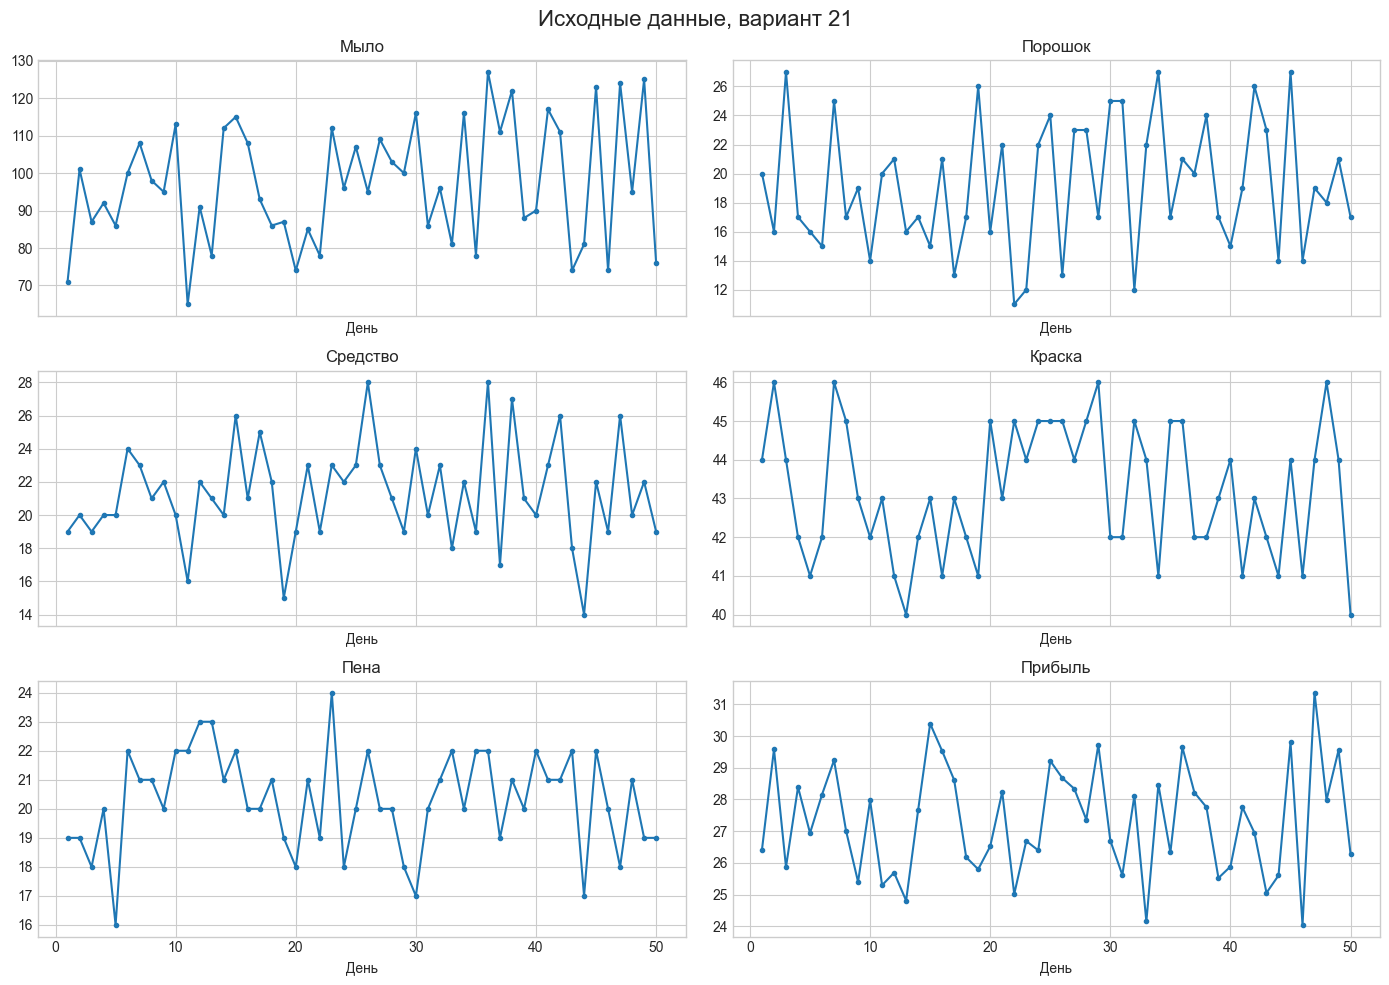

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for axis, column in zip(axes, PRODUCT_COLUMNS):
    axis.plot(data["day"], data[column], marker="o", markersize=3, linewidth=1.5)
    axis.set_title(PRODUCT_LABELS[column])
    axis.set_xlabel("День")

fig.suptitle(f"Исходные данные, вариант {VARIANT}", fontsize=16)
fig.tight_layout()
plt.show()

При окне 3 фильтр Савицкого-Голея с полиномом степени 2 почти не сглаживает ряд: квадратичный полином локально восстанавливает три точки окна. При увеличении окна сглаживание становится заметнее. Для прибыли окно 7 выглядит компромиссным: оно уже убирает часть локального шума, но еще не делает кривую чрезмерно плоской.

## Фильтрация

Параметры выбраны одинаковыми для всех рядов, чтобы сравнение методов было наглядным. Окно длиной 7 дней сглаживает недельные локальные колебания, но еще не уничтожает общую форму ряда.

In [16]:
WINDOW_SIZE = 7
SAVGOL_POLY_ORDER = 2
KALMAN_PROCESS_VARIANCE = 1.0
KALMAN_MEASUREMENT_VARIANCE = 16.0

filtered = {
    "moving_average": pd.DataFrame({"day": data["day"]}),
    "kalman": pd.DataFrame({"day": data["day"]}),
    "savitzky_golay": pd.DataFrame({"day": data["day"]}),
}

for column in PRODUCT_COLUMNS:
    values = data[column].to_numpy(dtype=float)
    filtered["moving_average"][column] = moving_average(values, WINDOW_SIZE)
    filtered["kalman"][column] = kalman_random_walk(
        values,
        process_variance=KALMAN_PROCESS_VARIANCE,
        measurement_variance=KALMAN_MEASUREMENT_VARIANCE,
    )
    filtered["savitzky_golay"][column] = savitzky_golay(values, WINDOW_SIZE, SAVGOL_POLY_ORDER)

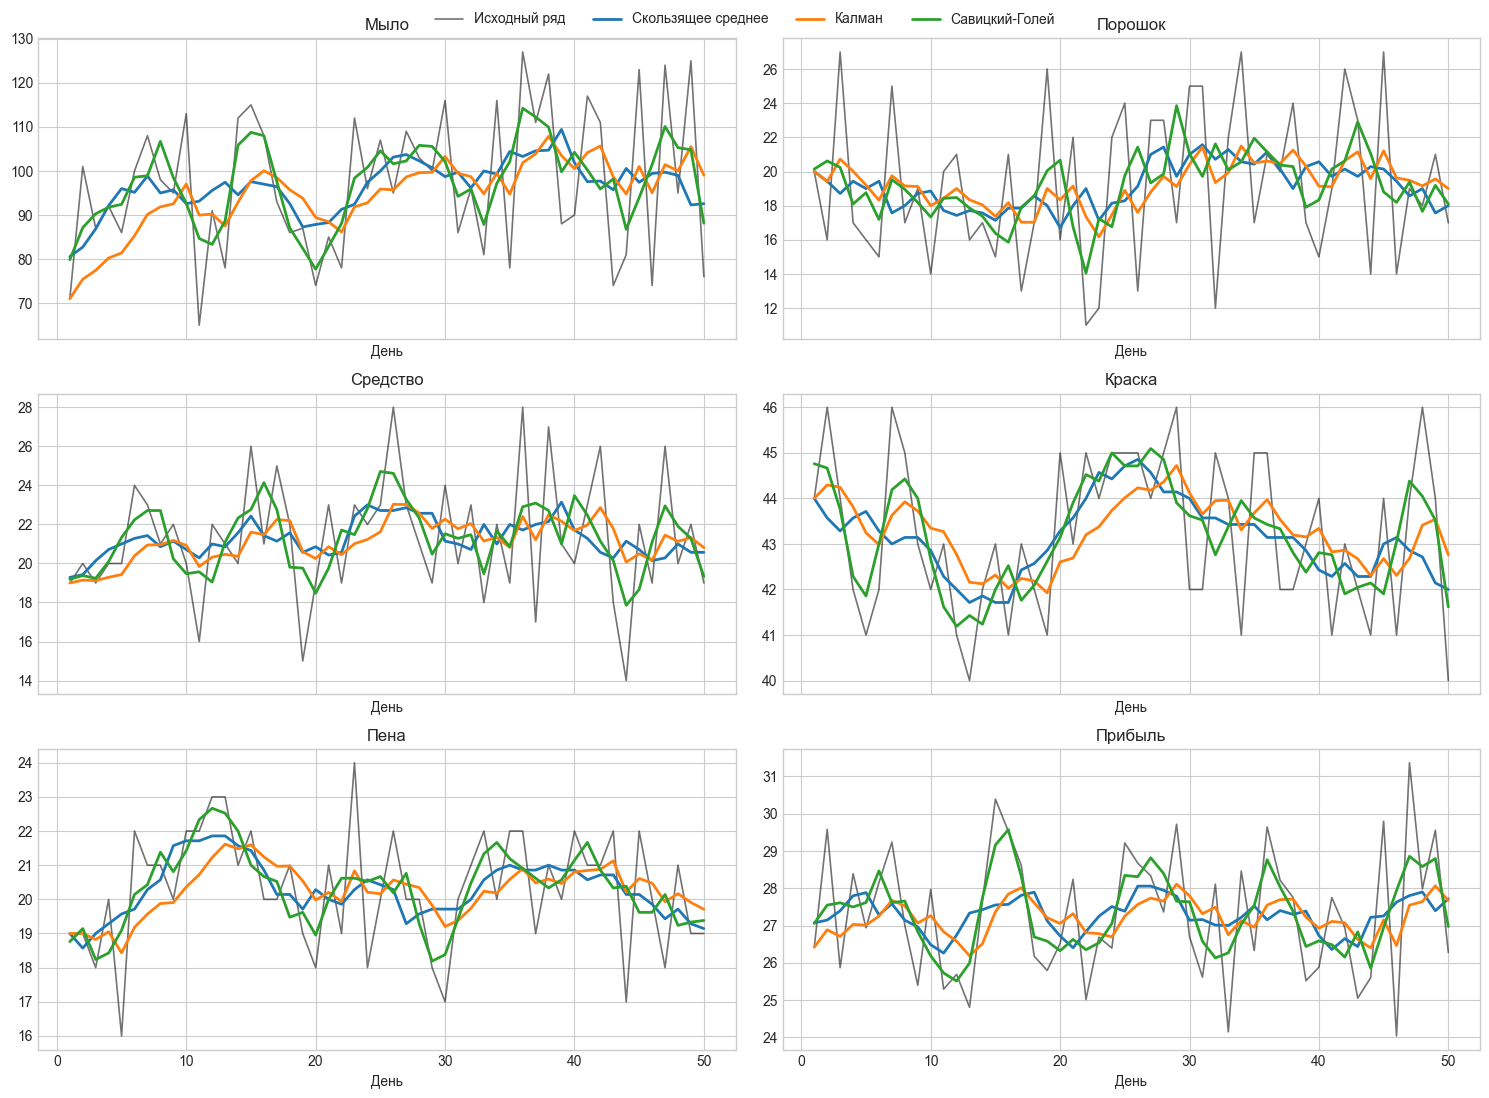

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()

for axis, column in zip(axes, PRODUCT_COLUMNS):
    axis.plot(data["day"], data[column], color="black", alpha=0.55, linewidth=1.2, label="Исходный ряд")
    axis.plot(filtered["moving_average"]["day"], filtered["moving_average"][column], linewidth=2, label="Скользящее среднее")
    axis.plot(filtered["kalman"]["day"], filtered["kalman"][column], linewidth=2, label="Калман")
    axis.plot(filtered["savitzky_golay"]["day"], filtered["savitzky_golay"][column], linewidth=2, label="Савицкий-Голей")
    axis.set_title(PRODUCT_LABELS[column])
    axis.set_xlabel("День")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
fig.tight_layout()
plt.show()

## Отдельный анализ прибыли

Прибыль является итоговым показателем, поэтому для нее полезно построить отдельный крупный график без остальных рядов.

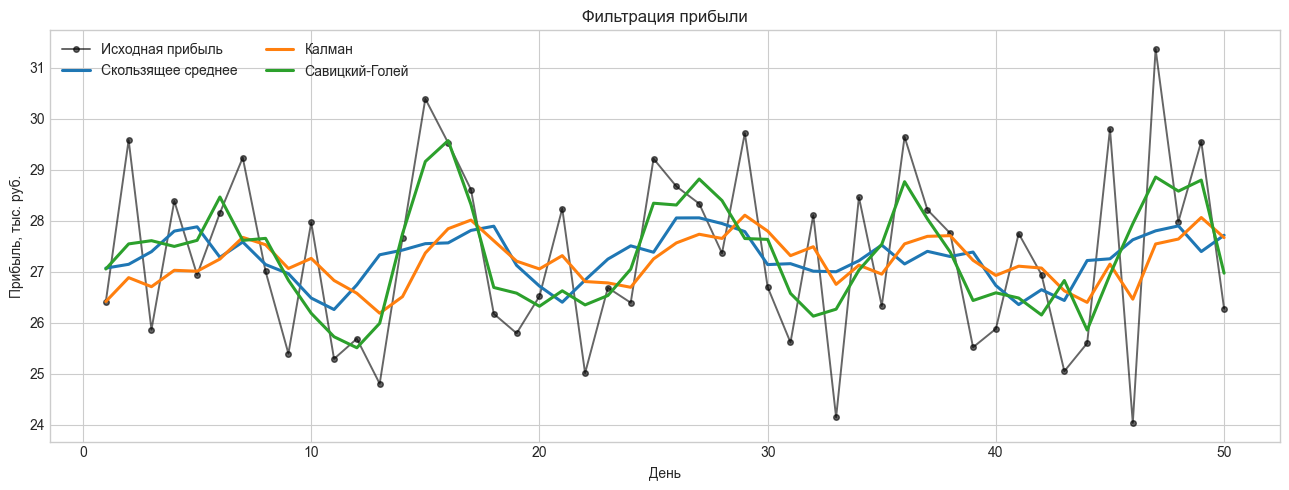

In [18]:
target_column = "profit"

fig, axis = plt.subplots(figsize=(13, 5))
axis.plot(data["day"], data[target_column], color="black", alpha=0.6, marker="o", markersize=4, linewidth=1.4, label="Исходная прибыль")
axis.plot(filtered["moving_average"]["day"], filtered["moving_average"][target_column], linewidth=2.2, label="Скользящее среднее")
axis.plot(filtered["kalman"]["day"], filtered["kalman"][target_column], linewidth=2.2, label="Калман")
axis.plot(filtered["savitzky_golay"]["day"], filtered["savitzky_golay"][target_column], linewidth=2.2, label="Савицкий-Голей")

axis.set_title("Фильтрация прибыли")
axis.set_xlabel("День")
axis.set_ylabel("Прибыль, тыс. руб.")
axis.legend(ncol=2)
fig.tight_layout()
plt.show()

## Численное сравнение

`rmse_to_original` показывает, насколько сильно фильтр отклоняется от исходного ряда. `smoothness_ratio` меньше 1 означает, что ряд стал более гладким по сравнению с исходным.

In [19]:
summary_tables = []

for column in PRODUCT_COLUMNS:
    table = filtering_summary(
        data[column],
        {
            "moving_average": filtered["moving_average"][column],
            "kalman": filtered["kalman"][column],
            "savitzky_golay": filtered["savitzky_golay"][column],
        },
    )
    table.insert(0, "series", PRODUCT_LABELS[column])
    summary_tables.append(table)

comparison = pd.concat(summary_tables, ignore_index=True)
comparison

,series,method,rmse_to_original,smoothness,smoothness_ratio
0,Мыло,moving_average,15.446881,3.118779,0.126419
1,Мыло,kalman,14.151378,3.891180,0.157728
2,Мыло,savitzky_golay,12.264550,6.872587,0.278578
3,Порошок,moving_average,4.304246,0.882048,0.125959
4,Порошок,kalman,3.742107,1.044124,0.149104
5,Порошок,savitzky_golay,4.248559,1.695874,0.242176
6,Средство,moving_average,2.891860,0.667365,0.144167
7,Средство,kalman,2.577885,0.733300,0.158411
8,Средство,savitzky_golay,2.501338,1.399094,0.302239
9,Краска,moving_average,1.454900,0.309505,0.148214


## Подбор размера окна

Сравним окна `3`, `5`, `7`, `9`, `11` на ряде прибыли. Чем больше окно, тем сильнее сглаживание, но тем выше риск потерять локальные особенности ряда.

In [20]:
window_sizes = [3, 5, 7, 9, 11]
profit_values = data["profit"].to_numpy(dtype=float)

window_results = []
window_filtered = {}

for window in window_sizes:
    ma_values = moving_average(profit_values, window)
    sg_values = savitzky_golay(profit_values, window, min(SAVGOL_POLY_ORDER, window - 1))
    window_filtered[("moving_average", window)] = ma_values
    window_filtered[("savitzky_golay", window)] = sg_values

    ma_summary = filtering_summary(profit_values, {"moving_average": ma_values}).iloc[0]
    sg_summary = filtering_summary(profit_values, {"savitzky_golay": sg_values}).iloc[0]
    window_results.extend(
        [
            {"method": "moving_average", "window": window, **ma_summary.to_dict()},
            {"method": "savitzky_golay", "window": window, **sg_summary.to_dict()},
        ]
    )

window_comparison = pd.DataFrame(window_results).drop(columns=["method"])
window_comparison.insert(0, "method", [row["method"] for row in window_results])
window_comparison

,method,window,rmse_to_original,smoothness,smoothness_ratio
0,moving_average,3,1.520937e+00,0.900613,0.350794
1,savitzky_golay,3,5.172829e-15,2.567356,1.000000
2,moving_average,5,1.434987e+00,0.528269,0.205764
3,savitzky_golay,5,1.420085e+00,1.121996,0.437024
4,moving_average,7,1.622162e+00,0.358186,0.139516
5,savitzky_golay,7,1.305590e+00,0.776450,0.302432
6,moving_average,9,1.662946e+00,0.231496,0.090169
7,savitzky_golay,9,1.464734e+00,0.570369,0.222162
8,moving_average,11,1.728333e+00,0.156009,0.060767
9,savitzky_golay,11,1.508672e+00,0.456985,0.177998


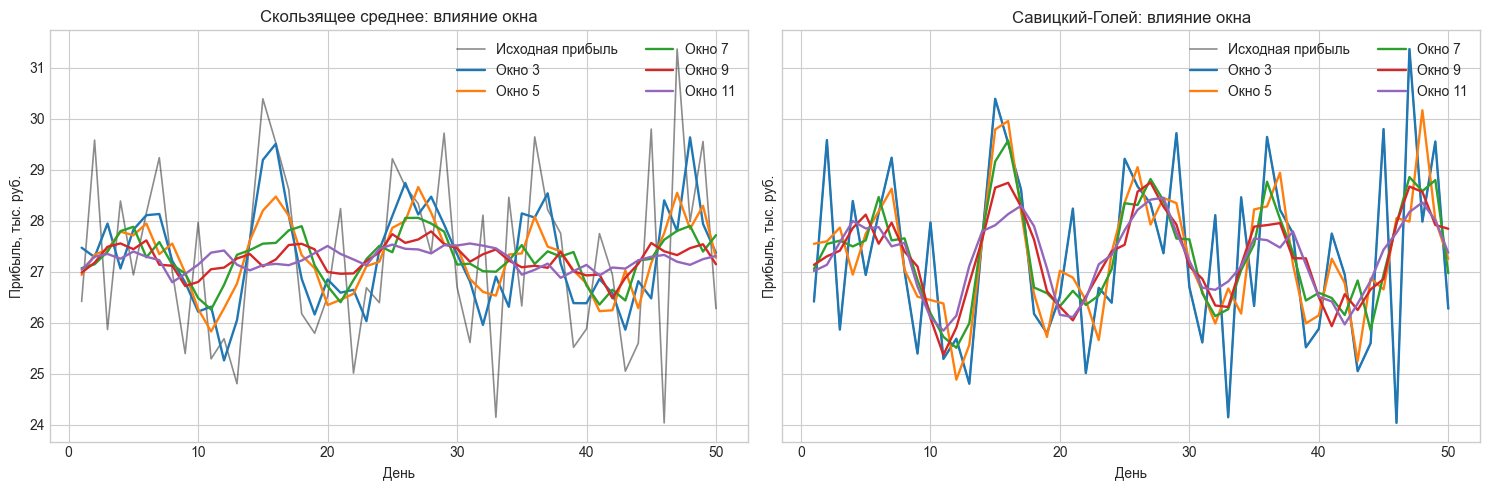

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

axes[0].plot(data["day"], data["profit"], color="black", alpha=0.45, linewidth=1.2, label="Исходная прибыль")
axes[1].plot(data["day"], data["profit"], color="black", alpha=0.45, linewidth=1.2, label="Исходная прибыль")

for window in window_sizes:
    axes[0].plot(data["day"], window_filtered[("moving_average", window)], linewidth=1.7, label=f"Окно {window}")
    axes[1].plot(data["day"], window_filtered[("savitzky_golay", window)], linewidth=1.7, label=f"Окно {window}")

axes[0].set_title("Скользящее среднее: влияние окна")
axes[1].set_title("Савицкий-Голей: влияние окна")

for axis in axes:
    axis.set_xlabel("День")
    axis.set_ylabel("Прибыль, тыс. руб.")
    axis.legend(ncol=2)

fig.tight_layout()
plt.show()

## Корреляции

In [22]:
corr = correlation_matrix(data, PRODUCT_COLUMNS)
corr

,soap,powder,cleaner,paint,foam,profit
soap,1.000000,0.270416,0.622266,0.124148,0.075836,0.738307
powder,0.270416,1.000000,0.043218,-0.049530,-0.110768,0.071828
cleaner,0.622266,0.043218,1.000000,0.189168,0.282961,0.539850
paint,0.124148,-0.049530,0.189168,1.000000,0.009032,0.328944
foam,0.075836,-0.110768,0.282961,0.009032,1.000000,-0.049510
profit,0.738307,0.071828,0.539850,0.328944,-0.049510,1.000000


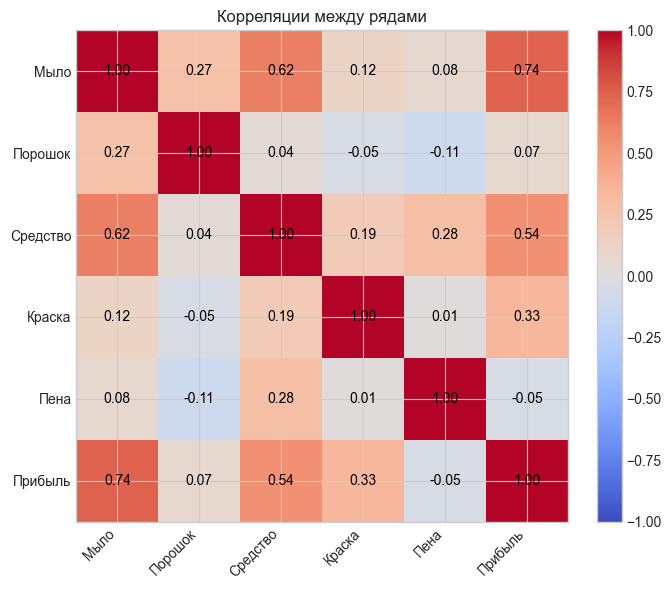

In [23]:
fig, axis = plt.subplots(figsize=(8, 6))
image = axis.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
axis.set_xticks(range(len(PRODUCT_COLUMNS)), [PRODUCT_LABELS[column] for column in PRODUCT_COLUMNS], rotation=45, ha="right")
axis.set_yticks(range(len(PRODUCT_COLUMNS)), [PRODUCT_LABELS[column] for column in PRODUCT_COLUMNS])

for row in range(len(PRODUCT_COLUMNS)):
    for col in range(len(PRODUCT_COLUMNS)):
        axis.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", color="black")

fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
axis.set_title("Корреляции между рядами")
fig.tight_layout()
plt.show()

## Периодичность и автокорреляция

In [24]:
max_lag = 20
period_rows = []

for column in PRODUCT_COLUMNS:
    lag, coefficient = dominant_period(data[column], max_lag=max_lag)
    period_rows.append({"series": PRODUCT_LABELS[column], "dominant_lag": lag, "autocorrelation": coefficient})

period_table = pd.DataFrame(period_rows)
period_table

,series,dominant_lag,autocorrelation
0,Мыло,11,0.339737
1,Порошок,9,0.248189
2,Средство,9,0.242871
3,Краска,1,0.216122
4,Пена,2,0.215363
5,Прибыль,11,0.323804


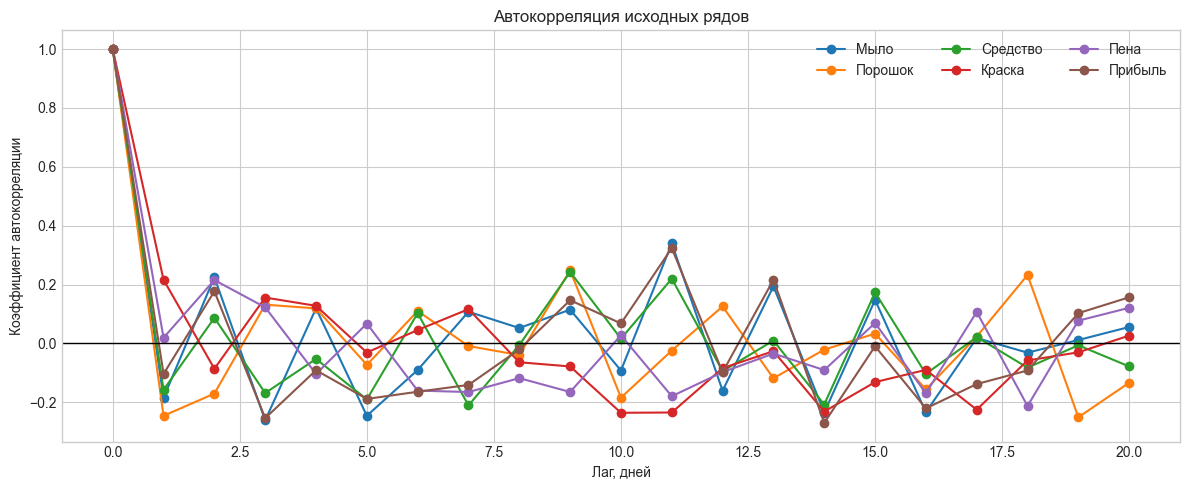

In [25]:
fig, axis = plt.subplots(figsize=(12, 5))

for column in PRODUCT_COLUMNS:
    coefficients = autocorrelation(data[column], max_lag=max_lag)
    axis.plot(range(len(coefficients)), coefficients, marker="o", label=PRODUCT_LABELS[column])

axis.axhline(0, color="black", linewidth=1)
axis.set_title("Автокорреляция исходных рядов")
axis.set_xlabel("Лаг, дней")
axis.set_ylabel("Коэффициент автокорреляции")
axis.legend(ncol=3)
fig.tight_layout()
plt.show()

## Выводы по варианту 21

По исходным графикам видно, что наиболее изменчивый ряд — продажи мыла: значения меняются от 65 до 127 штук при среднем около 97. Остальные товарные ряды имеют меньший разброс, а прибыль находится в диапазоне примерно от 24.04 до 31.37 тыс. руб.

Все три фильтра заметно уменьшают локальные колебания. По метрике `smoothness_ratio` для прибыли скользящее среднее дает самое сильное сглаживание: около 0.14 от исходной изменчивости первых разностей. Фильтр Калмана близок к нему по гладкости, но ведет себя более последовательно: новая точка влияет на оценку постепенно. Фильтр Савицкого-Голея меньше отклоняется от исходной прибыли по RMSE: около 1.31 против 1.62 у скользящего среднего и 1.48 у Калмана, поэтому лучше сохраняет форму локальных подъемов и спадов.

Корреляционная матрица показывает, что прибыль сильнее всего связана с продажами мыла: коэффициент корреляции около 0.74. Также заметная положительная связь есть со средством: около 0.54. Связь прибыли с порошком и пеной слабая, поэтому по этим данным они хуже объясняют изменение прибыли.

Автокорреляция не показывает сильной регулярной сезонности, но для прибыли и мыла наиболее выражен лаг 11 дней: коэффициенты около 0.32 и 0.34 соответственно. Это можно интерпретировать как слабый повторяющийся паттерн, но для уверенного вывода данных мало: в варианте всего 50 наблюдений.

Для этой задачи наиболее удачным выглядит фильтр Савицкого-Голея с окном 7 и полиномом степени 2. Он сглаживает шум слабее, чем скользящее среднее, зато лучше сохраняет форму ряда прибыли и дает меньшее отклонение от исходных значений по RMSE. Скользящее среднее удобно как базовый ориентир, а фильтр Калмана полезен как последовательная оценка скрытого уровня продаж, но для визуального анализа данных Савицкий-Голей дает лучший баланс между сглаживанием и сохранением локальной динамики.